# Verify Conservative Crop Mask Remapping

This notebook verifies the remapped crop mask from fine to coarse SIF grid using:
1. Area conservation check
2. Visual comparison over Africa
3. Single-cell spot check

In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ---- Update only if your paths differ ----
CROP_MASK_PATH = '/home/chc-shrad/DATA/Crop_yield_forecasting/Crop_masks/lu_et_al/Global-cropland-percentage-map.nc'
CROP_MASK_VAR = 'crop_mask'
REMAPPED_PATH = '/home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/crop_mask_fraction_on_sif_grid_conservative.nc'

In [2]:
EARTH_RADIUS_KM = 6371.0

def infer_grid_step_deg(coord):
    vals = np.asarray(coord.values, dtype=float)
    return float(np.abs(np.median(np.diff(vals))))

def compute_cell_area(lat_centers, delta_lon_deg, delta_lat_deg):
    lat_vals = np.asarray(lat_centers.values, dtype=float)
    dlon_rad = np.deg2rad(abs(delta_lon_deg))
    half_dlat = 0.5 * abs(delta_lat_deg)

    lat_n = np.deg2rad(lat_vals + half_dlat)
    lat_s = np.deg2rad(lat_vals - half_dlat)
    area_1d = (EARTH_RADIUS_KM**2) * dlon_rad * np.abs(np.sin(lat_n) - np.sin(lat_s))
    return xr.DataArray(area_1d, coords={'lat': lat_centers}, dims=('lat',), name='cell_area_km2')

def compute_edges_from_centers(centers):
    centers = np.asarray(centers, dtype=float)
    if centers[0] > centers[-1]:
        centers = centers[::-1]
    mid = 0.5 * (centers[:-1] + centers[1:])
    first = centers[0] - 0.5 * (centers[1] - centers[0])
    last = centers[-1] + 0.5 * (centers[-1] - centers[-2])
    return np.concatenate(([first], mid, [last]))

In [13]:
lon_min, lon_max = -25.27, 52.28
lat_min, lat_max = -36.13, 36.62

In [15]:
# Load fine crop mask
fine_ds = xr.open_dataset(CROP_MASK_PATH)
fine_crop_pct = fine_ds[CROP_MASK_VAR].sel(longitude=slice(lon_min, lon_max), latitude=slice(lat_max, lat_min))
rename_map = {}
if 'latitude' in fine_crop_pct.coords:
    rename_map['latitude'] = 'lat'
if 'longitude' in fine_crop_pct.coords:
    rename_map['longitude'] = 'lon'
if rename_map:
    fine_crop_pct = fine_crop_pct.rename(rename_map)

# Load remapped coarse result
remap_ds = xr.open_dataset(REMAPPED_PATH)
coarse_crop_fraction = remap_ds['crop_fraction'].sel(lon=slice(lon_min, lon_max), lat=slice(lat_min, lat_max))
coarse_crop_area = remap_ds['coarse_crop_area_km2']
coarse_cell_area = remap_ds['coarse_cell_area_km2']

fine_dlat = infer_grid_step_deg(fine_crop_pct['lat'])
fine_dlon = infer_grid_step_deg(fine_crop_pct['lon'])
coarse_dlat = infer_grid_step_deg(coarse_crop_fraction['lat'])
coarse_dlon = infer_grid_step_deg(coarse_crop_fraction['lon'])

print(f'Fine grid:   dlat={fine_dlat:.6f}, dlon={fine_dlon:.6f}')
print(f'Coarse grid: dlat={coarse_dlat:.6f}, dlon={coarse_dlon:.6f}')
print(f'Remapped file: {Path(REMAPPED_PATH)}')

Fine grid:   dlat=0.004167, dlon=0.004167
Coarse grid: dlat=0.050000, dlon=0.050000
Remapped file: /home/chc-source/shrad/Scripts/Funded_projects/2026/crop_yield_forecasting/data/crop_mask_fraction_on_sif_grid_conservative.nc


In [16]:
# Verification 1: Area conservation
fine_row_area = compute_cell_area(fine_crop_pct['lat'], fine_dlon, fine_dlat)
fine_cell_area = fine_row_area.broadcast_like(fine_crop_pct)
fine_crop_fraction = (fine_crop_pct).clip(0.0, 1.0)
fine_crop_area = fine_crop_fraction * fine_cell_area

fine_total = float(fine_crop_area.sum(skipna=True).values)
coarse_total = float((coarse_crop_fraction * coarse_cell_area).sum(skipna=True).values)
ratio = coarse_total / fine_total
rel_err_pct = abs(coarse_total - fine_total) / fine_total * 100.0

print(f'Fine total crop area   (km^2): {fine_total:,.6f}')
print(f'Coarse total crop area (km^2): {coarse_total:,.6f}')
print(f'Conservation ratio (coarse/fine): {ratio:.10f}')
print(f'Relative error (%): {rel_err_pct:.8f}')

Fine total crop area   (km^2): 3,143,779.848099
Coarse total crop area (km^2): 3,140,816.797193
Conservation ratio (coarse/fine): 0.9990574878
Relative error (%): 0.09425122


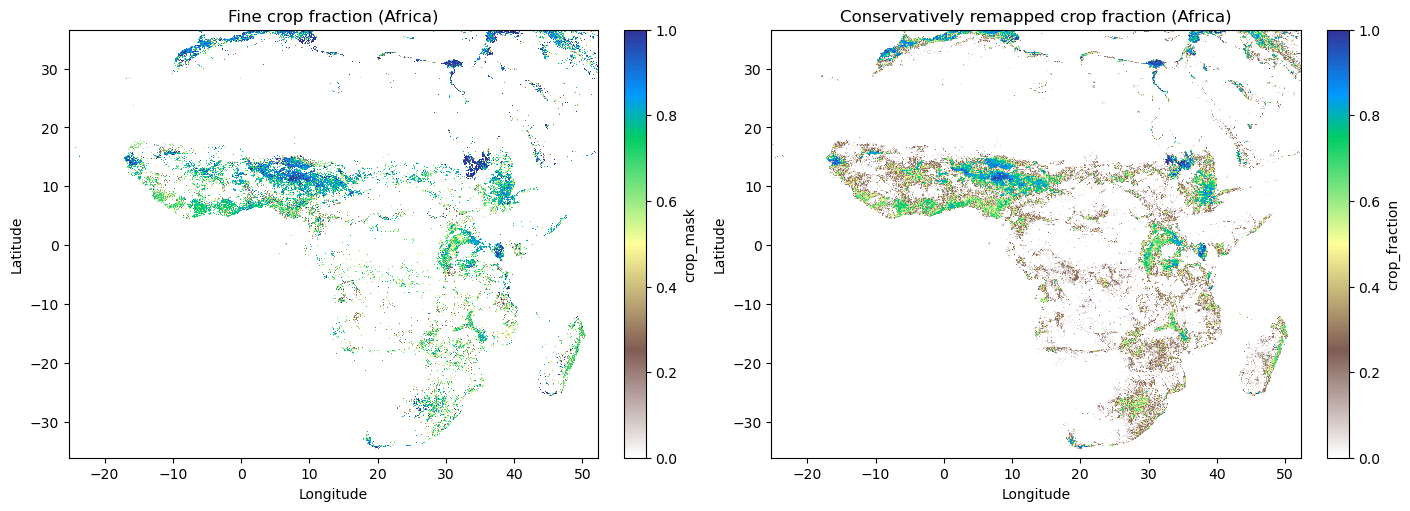

In [17]:
# Verification 2: Visual check over Africa

cmap = 'terrain_r'
fine_africa = fine_crop_fraction.where(
    (fine_crop_fraction['lon'] >= lon_min) & (fine_crop_fraction['lon'] <= lon_max) &
    (fine_crop_fraction['lat'] >= lat_min) & (fine_crop_fraction['lat'] <= lat_max),
    drop=True
)
coarse_africa = coarse_crop_fraction.where(
    (coarse_crop_fraction['lon'] >= lon_min) & (coarse_crop_fraction['lon'] <= lon_max) &
    (coarse_crop_fraction['lat'] >= lat_min) & (coarse_crop_fraction['lat'] <= lat_max),
    drop=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fine_africa.plot(ax=axes[0], cmap=cmap, vmin=0, vmax=1, add_colorbar=True)
axes[0].set_title('Fine crop fraction (Africa)')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

coarse_africa.plot(ax=axes[1], cmap=cmap, vmin=0, vmax=1, add_colorbar=True)
axes[1].set_title('Conservatively remapped crop fraction (Africa)')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.show()

## Notes
- If the conservation ratio is very close to 1, remapping is area-conservative.
- Small numerical differences are expected from floating-point arithmetic and edge conventions.